In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from pathlib import Path
import sys

sys.path.insert(0, str(Path(r"C:\Users\user\Documents\Stats\Chess_Project")))
from config import *

In [4]:
from src.download_save_load import download_chess_games

download_chess_games(MY_CHESS_USERNAME)

✓ File already exists: C:\Users\user\Documents\Stats\Chess_Project\data\raw\ChessGames_ParpasP.json
  To download fresh data, use force_download=True


In [5]:
from src.download_save_load import process_and_save_chess_data

games_df, moves_df = process_and_save_chess_data()

📂 Loading raw games from: C:\Users\user\Documents\Stats\Chess_Project\data\raw\ChessGames_ParpasP.json
✓ Loaded 2379 raw games

🔄 Processing 2379 games...
✅ Created 2379 games and 148539 moves
✓ Saved 2379 games to C:\Users\user\Documents\Stats\Chess_Project\data\processed\games_df_ParpasP.csv
✓ Saved 148539 moves to C:\Users\user\Documents\Stats\Chess_Project\data\processed\moves_df_ParpasP.csv
  File sizes: 1378.9 KB, 25515.5 KB


In [6]:
import asyncio

asyncio.set_event_loop_policy(asyncio.WindowsProactorEventLoopPolicy())

In [7]:
moves_df.head(10)

,uuid,link_id,time_class,time_control,move_no,move_index,turn,move,eval_before,eval_after,clock,clock_sec,my_move,fen,end_time
0,71ba5026-3e2a-11f1-a0f1-86ad2101000f,167657102686,bullet,60+1,1,0,white,d4,0,28,0:01:00.9,60.9,True,rnbqkbnr/pppppppp/8/8/3P4/8/PPP1PPPP/RNBQKBNR ...,1776848860
1,71ba5026-3e2a-11f1-a0f1-86ad2101000f,167657102686,bullet,60+1,1,1,black,e5,28,116,0:01:00.8,60.8,False,rnbqkbnr/pppp1ppp/8/4p3/3P4/8/PPP1PPPP/RNBQKBN...,1776848860
2,71ba5026-3e2a-11f1-a0f1-86ad2101000f,167657102686,bullet,60+1,2,2,white,c4,116,-47,0:01:01.4,61.4,True,rnbqkbnr/pppp1ppp/8/4p3/2PP4/8/PP2PPPP/RNBQKBN...,1776848860
3,71ba5026-3e2a-11f1-a0f1-86ad2101000f,167657102686,bullet,60+1,2,3,black,Nc6,-47,54,0:01:01.5,61.5,False,r1bqkbnr/pppp1ppp/2n5/4p3/2PP4/8/PP2PPPP/RNBQK...,1776848860
4,71ba5026-3e2a-11f1-a0f1-86ad2101000f,167657102686,bullet,60+1,3,4,white,dxe5,54,18,0:01:01.5,61.5,True,r1bqkbnr/pppp1ppp/2n5/4P3/2P5/8/PP2PPPP/RNBQKB...,1776848860
5,71ba5026-3e2a-11f1-a0f1-86ad2101000f,167657102686,bullet,60+1,3,5,black,Nxe5,18,15,0:01:01.1,61.1,False,r1bqkbnr/pppp1ppp/8/4n3/2P5/8/PP2PPPP/RNBQKBNR...,1776848860
6,71ba5026-3e2a-11f1-a0f1-86ad2101000f,167657102686,bullet,60+1,4,6,white,Nf3,15,14,0:01:01.4,61.4,True,r1bqkbnr/pppp1ppp/8/4n3/2P5/5N2/PP2PPPP/RNBQKB...,1776848860
7,71ba5026-3e2a-11f1-a0f1-86ad2101000f,167657102686,bullet,60+1,4,7,black,Nxc4,14,16,0:01:00.8,60.8,False,r1bqkbnr/pppp1ppp/8/8/2n5/5N2/PP2PPPP/RNBQKB1R...,1776848860
8,71ba5026-3e2a-11f1-a0f1-86ad2101000f,167657102686,bullet,60+1,5,8,white,Nc3,16,12,0:00:58.3,58.3,True,r1bqkbnr/pppp1ppp/8/8/2n5/2N2N2/PP2PPPP/R1BQKB...,1776848860
9,71ba5026-3e2a-11f1-a0f1-86ad2101000f,167657102686,bullet,60+1,5,9,black,Bb4,12,160,0:00:57.7,57.7,False,r1bqk1nr/pppp1ppp/8/8/1bn5/2N2N2/PP2PPPP/R1BQK...,1776848860


In [23]:
from src.cache import run_chess_analysis

_, moves_df = run_chess_analysis(
    games_df, moves_df, time_control=None, n_games=-1, depth=10, use_cache=True
)

✅ Games selected: 2379
✅ Moves selected: 148539
Loaded 148539 cached evaluations


Analyzing moves:   0%|          | 0/148539 [00:00<?, ?move/s]

💾 Saved 148539 evaluations to cache                               

Total moves analyzed: 148539
Games analyzed: 2377
Cache hits: 148539
New evaluations: 0
Cache size: 148539 total entries


In [24]:
# Check columns
print("games_df columns: ", games_df.columns.tolist())
print("=" * 50)
print("moves_df columns: ", moves_df.columns.tolist())

games_df columns:  ['uuid', 'link_id', 'link', 'time_class', 'time_control', 'rated', 'white', 'white_rating', 'black', 'black_rating', 'rating_diff', 'opening', 'simple_opening', 'eco_code', 'my_color', 'result', 'white_accuracy', 'black_accuracy', 'Time', 'end_time', 'moves']
moves_df columns:  ['uuid', 'link_id', 'time_class', 'time_control', 'move_no', 'move_index', 'turn', 'move', 'eval_before', 'eval_after', 'clock', 'clock_sec', 'my_move', 'fen', 'end_time', 'depth']


In [56]:
games_df.head()

,uuid,link_id,link,time_class,time_control,rated,white,white_rating,black,black_rating,...,eco_code,my_color,result,white_accuracy,black_accuracy,Time,end_time,moves,is_win,is_loss
0,71ba5026-3e2a-11f1-a0f1-86ad2101000f,167657102686,https://www.chess.com/game/live/167657102686,bullet,60+1,True,ParpasP,877,Anurag7381,782,...,/www.chess.com/openings/Queens-Pawn-Opening-Mi...,White,Win,NaN,NaN,2026-04-22 11:07:40+02:00,1776848860,d4|e5|c4|Nc6|dxe5|Nxe5|Nf3|Nxc4|Nc3|Bb4|e4|Bxc...,False,False
1,2373403c-3e2a-11f1-8849-28ad8d01000f,167657034790,https://www.chess.com/game/live/167657034790,bullet,60+1,True,donut1,870,ParpasP,871,...,/www.chess.com/openings/Closed-Sicilian-Defens...,Black,Win,NaN,NaN,2026-04-22 11:05:35+02:00,1776848735,e4|c5|Nc3|e6|d3|d5|exd5|exd5|Nf3|d4|Ne4|Nc6|Be...,False,False
2,b9037a8d-3e29-11f1-8849-28ad8d01000f,167656944644,https://www.chess.com/game/live/167656944644,bullet,60+1,True,ParpasP,863,Roszek8,879,...,/www.chess.com/openings/Queens-Gambit-Declined...,White,Loss,NaN,NaN,2026-04-22 11:03:29+02:00,1776848609,d4|d5|c4|Bf5|Nc3|e6|Qb3|b6|e3|Nf6|Be2|Be7|Nf3|...,False,False
3,74a00043-3e29-11f1-8849-28ad8d01000f,167656886854,https://www.chess.com/game/live/167656886854,bullet,60+1,True,mustafe6627,906,ParpasP,871,...,/www.chess.com/openings/Queens-Pawn-Opening-Bl...,Black,Loss,NaN,NaN,2026-04-22 11:00:31+02:00,1776848431,d4|d5|e4|dxe4|Bc4|Nf6|Ne2|Nc6|Nbc3|Bg4|h3|Bh5|...,False,False
4,cbcfa136-3e25-11f1-8849-28ad8d01000f,167656092276,https://www.chess.com/game/live/167656092276,bullet,60+1,True,ParpasP,879,ContreUnoFR,848,...,/www.chess.com/openings/London-System...4.e3-B...,White,Win,NaN,NaN,2026-04-22 10:34:36+02:00,1776846876,d4|d5|c4|c6|Nc3|Bf5|Nf3|Nf6|Bf4|e6|e3|Bd6|Bg3|...,False,False


In [25]:
print(games_df["result"].value_counts())
print(games_df["my_color"].value_counts())

result
Win     1308
Loss    1025
Draw      46
Name: count, dtype: int64
my_color
White    1190
Black    1189
Name: count, dtype: int64


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create a win/loss indicator (excluding draws)
games_df["is_win"] = games_df["result"] == "Win"
games_df["is_loss"] = games_df["result"] == "Loss"

# Win rate by my_color
win_rate = games_df.groupby("my_color")["is_win"].mean() * 100
loss_rate = games_df.groupby("my_color")["is_loss"].mean() * 100

results_df = pd.DataFrame(
    {"Win %": win_rate, "Loss %": loss_rate, "Draw %": 100 - win_rate - loss_rate}
)

print("Results by color:")
print(results_df.round(1))

Results by color:
          Win %  Loss %  Draw %
my_color                       
Black      54.0    44.4     1.6
White      56.0    41.8     2.3


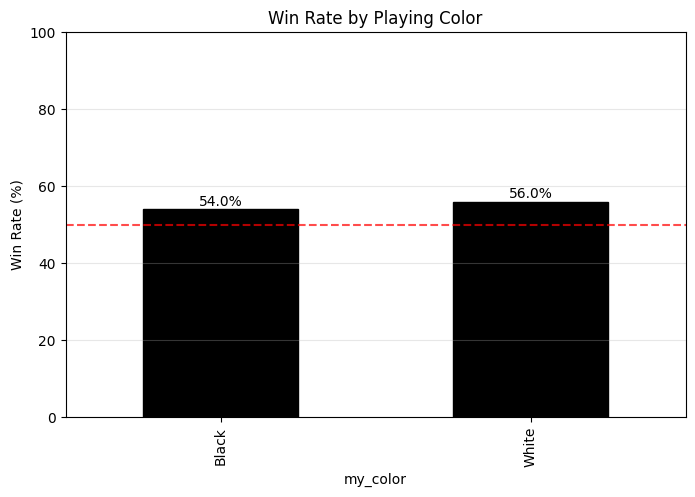

In [58]:
# Bar plot
fig, ax = plt.subplots(figsize=(8, 5))
win_rate.sort_values().plot(
    kind="bar",
    color=["white" if c == "white" else "black" for c in win_rate.index],
    edgecolor="black",
    ax=ax,
)
plt.ylim(0, 100)
plt.ylabel("Win Rate (%)")
plt.title("Win Rate by Playing Color")
plt.axhline(y=50, color="red", linestyle="--", alpha=0.7)
plt.grid(axis="y", alpha=0.3)

# Add value labels
for i, v in enumerate(win_rate):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center")

plt.show()

In [27]:
from scipy.stats import chi2_contingency

# Filter to just wins/losses (exclude draws for cleaner test)
wl_df = games_df[games_df["result"].isin(["Win", "Loss"])].copy()

contingency = pd.crosstab(wl_df["my_color"], wl_df["result"])
print("\nContingency table:")
print(contingency)

chi2, p, dof, expected = chi2_contingency(contingency)
print(f"\nChi-square: {chi2:.3f}")
print(f"p-value: {p:.4f}")

if p < 0.05:
    print("\n✓ Color DOES significantly affect outcome")
else:
    print("\n✗ No significant color advantage found")


Contingency table:
result    Loss  Win
my_color           
Black      528  642
White      497  666

Chi-square: 1.261
p-value: 0.2614

✗ No significant color advantage found


In [28]:
# Create rating diff (positive = you're stronger)
games_df["rating_advantage"] = games_df["white_rating"] - games_df["black_rating"]

# Adjust based on my_color
games_df["my_advantage"] = games_df.apply(
    lambda row: (
        row["rating_advantage"]
        if row["my_color"] == "white"
        else -row["rating_advantage"]
    ),
    axis=1,
)

# Create buckets
games_df["advantage_bucket"] = pd.cut(
    games_df["my_advantage"],
    bins=[-float("inf"), -200, -50, 50, 200, float("inf")],
    labels=[
        "Much weaker",
        "Slightly weaker",
        "Equal",
        "Slightly stronger",
        "Much stronger",
    ],
)

# Win rate by color AND advantage
pivot = games_df.groupby(["my_color", "advantage_bucket"])["is_win"].mean() * 100
pivot_table = pivot.unstack()

print("\nWin rate by color and rating advantage (%):")
print(pivot_table.round(1))


Win rate by color and rating advantage (%):
advantage_bucket  Much weaker  Slightly weaker  Equal  Slightly stronger  \
my_color                                                                   
Black                    50.0             24.6   51.8               86.0   
White                    77.1             78.9   54.0               32.8   

advantage_bucket  Much stronger  
my_color                         
Black                      72.9  
White                      33.3  


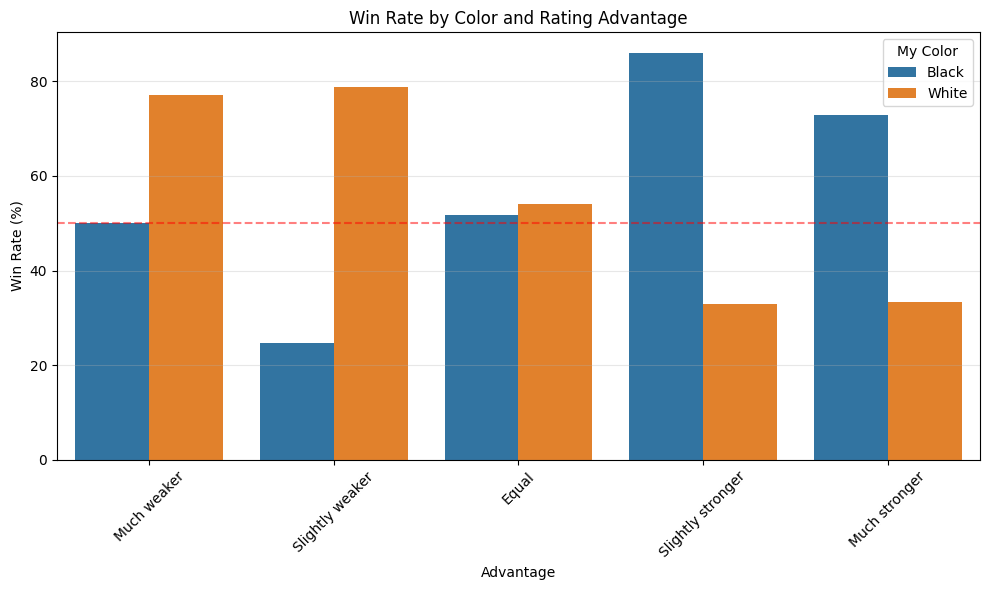

In [62]:
# Melt for seaborn
plot_df = pivot_table.reset_index().melt(
    id_vars="my_color", var_name="Advantage", value_name="Win Rate"
)

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df, x="Advantage", y="Win Rate", hue="my_color")
plt.axhline(y=50, color="red", linestyle="--", alpha=0.5)
plt.title("Win Rate by Color and Rating Advantage")
plt.ylabel("Win Rate (%)")
plt.xticks(rotation=45)
plt.legend(title="My Color")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [63]:
# See your most common openings
print("Your most frequent openings:")
print(games_df["simple_opening"].value_counts().head(10))

# Also check by color
print("\nAs White:")
print(
    games_df[games_df["my_color"] == "White"]["simple_opening"].value_counts().head(10)
)

print("\nAs Black:")
print(
    games_df[games_df["my_color"] == "Black"]["simple_opening"].value_counts().head(10)
)

Your most frequent openings:
simple_opening
Queen's Gambit Declined    465
Sicilian Defense           456
Quenn's Pawn Opening       172
Queen's Gambit Accepted    153
Caro-Kann Defense          148
Englund Gambit             108
Slav Defense               102
Indian Game                 88
King's Indian Defense       80
Alapin Sicilian Defense     46
Name: count, dtype: int64

As White:
simple_opening
Queen's Gambit Declined    412
Queen's Gambit Accepted    153
Quenn's Pawn Opening       110
Englund Gambit              95
Slav Defense                81
King's Indian Defense       72
Modern Defense              27
English Opening             23
Old Benoni Defense          18
Indian Game                 16
Name: count, dtype: int64

As Black:
simple_opening
Sicilian Defense           452
Caro-Kann Defense          142
Indian Game                 72
Quenn's Pawn Opening        62
Queen's Gambit Declined     53
Alapin Sicilian Defense     44
Closed Sicilian Defense     32
Slav Defense   

In [64]:
# Calculate win rate by opening (excluding draws for clarity)
openings_winrate = (
    games_df.groupby("simple_opening")
    .agg({"is_win": "mean", "uuid": "count"})  # number of games
    .round(3)
)

openings_winrate["win_pct"] = openings_winrate["is_win"] * 100
openings_winrate = openings_winrate[openings_winrate["uuid"] >= 5]  # minimum 5 games

print("\nBest openings by win rate:")
print(openings_winrate.sort_values("win_pct", ascending=False).head(10))

print("\nWorst openings by win rate:")
print(openings_winrate.sort_values("win_pct", ascending=True).head(10))


Best openings by win rate:
                      is_win  uuid  win_pct
simple_opening                             
Grob                   0.833     6     83.3
London System          0.824    17     82.4
King's Gambit          0.818    11     81.8
Giuco Piano            0.818    11     81.8
Undefined              0.750     8     75.0
Petrov's Defense       0.750     8     75.0
French Defense         0.722    18     72.2
Scotch Game            0.714    14     71.4
Scandinavian Defense   0.688    16     68.8
King's Pawn Opening    0.684    19     68.4

Worst openings by win rate:
                         is_win  uuid  win_pct
simple_opening                                
Vienna Game               0.200     5     20.0
King's Indian Attack      0.333     6     33.3
Grunfeld Defense          0.333     6     33.3
Queens Gambit             0.357    14     35.7
King's Indian Defense     0.375    80     37.5
Torre Attack              0.400     5     40.0
Colle System              0.417    12  

In [65]:
# Best opening with White
white_openings = (
    games_df[games_df["my_color"] == "White"]
    .groupby("simple_opening")
    .agg({"is_win": lambda x: (x.mean() * 100), "uuid": "count"})
)
white_openings = white_openings[white_openings["uuid"] >= 3]
print("Best openings as White:")
print(white_openings.sort_values("is_win", ascending=False).head(5))

# Best opening as Black
black_openings = (
    games_df[games_df["my_color"] == "Black"]
    .groupby("simple_opening")
    .agg({"is_win": lambda x: (x.mean() * 100), "uuid": "count"})
)
black_openings = black_openings[black_openings["uuid"] >= 3]
print("\nBest openings as Black:")
print(black_openings.sort_values("is_win", ascending=False).head(5))

Best openings as White:
                  is_win  uuid
simple_opening                
Petrov's Defense   100.0     3
Sicilian Defense   100.0     4
King's Gambit       90.0    10
London System       80.0     5
French Defense      80.0     5

Best openings as Black:
                          is_win  uuid
simple_opening                        
Scandinavian Defense  100.000000     6
Giuco Piano            87.500000     8
Grob                   83.333333     6
London System          83.333333    12
Scotch Game            76.923077    13


In [66]:
# Focus on your two main openings
main_openings = ["Queen's Gambit Declined", "Sicilian Defense"]

for opening in main_openings:
    print(f"\n{'='*50}")
    print(f"ANALYZING: {opening}")
    print("=" * 50)

    opening_games = games_df[games_df["simple_opening"] == opening]

    # By color
    print(f"\nTotal games: {len(opening_games)}")
    print(
        f"Win rate as White: {opening_games[opening_games['my_color']=='White']['is_win'].mean()*100:.1f}%"
    )
    print(
        f"Win rate as Black: {opening_games[opening_games['my_color']=='Black']['is_win'].mean()*100:.1f}%"
    )

    # By rating advantage
    print("\nWin rate by rating advantage:")
    adv_table = opening_games.groupby("advantage_bucket")["is_win"].mean() * 100
    print(adv_table.round(1))

    # Show results distribution
    print("\nResult distribution:")
    print(opening_games["result"].value_counts(normalize=True).round(3) * 100)


ANALYZING: Queen's Gambit Declined

Total games: 465
Win rate as White: 58.7%
Win rate as Black: 49.1%

Win rate by rating advantage:
advantage_bucket
Much weaker           83.3
Slightly weaker       77.8
Equal                 55.3
Slightly stronger     31.6
Much stronger        100.0
Name: is_win, dtype: float64

Result distribution:
result
Win     57.6
Loss    40.0
Draw     2.4
Name: proportion, dtype: float64

ANALYZING: Sicilian Defense

Total games: 456
Win rate as White: 100.0%
Win rate as Black: 51.8%

Win rate by rating advantage:
advantage_bucket
Much weaker          66.7
Slightly weaker      22.2
Equal                51.9
Slightly stronger    78.9
Much stronger        75.0
Name: is_win, dtype: float64

Result distribution:
result
Win     52.2
Loss    46.9
Draw     0.9
Name: proportion, dtype: float64


In [67]:
# Merge games with moves to get average accuracy per opening
# First, get average accuracy per game for your color
games_df["my_accuracy"] = games_df.apply(
    lambda row: (
        row["white_accuracy"] if row["my_color"] == "White" else row["black_accuracy"]
    ),
    axis=1,
)

# Compare accuracy across openings
opening_accuracy = (
    games_df.groupby("simple_opening")
    .agg({"my_accuracy": "mean", "is_win": "mean", "uuid": "count"})
    .round(2)
)

opening_accuracy = opening_accuracy[opening_accuracy["uuid"] >= 5]
opening_accuracy["win_pct"] = opening_accuracy["is_win"] * 100

# Find openings where you're accurate but losing (potential bad strategy)
opening_accuracy["accuracy_win_gap"] = (
    opening_accuracy["my_accuracy"] - opening_accuracy["win_pct"]
)

print("\nOpenings where accuracy doesn't translate to wins:")
print(opening_accuracy.sort_values("accuracy_win_gap", ascending=False).head(10))

print("\nOpenings where you win despite low accuracy (tactical/scrappy):")
print(opening_accuracy.sort_values("accuracy_win_gap", ascending=True).head(10))


Openings where accuracy doesn't translate to wins:
                         my_accuracy  is_win  uuid  win_pct  accuracy_win_gap
simple_opening                                                               
Vienna Game                    76.78    0.20     5     20.0             56.78
King's Indian Attack           82.07    0.33     6     33.0             49.07
Grunfeld Defense               74.81    0.33     6     33.0             41.81
Torre Attack                   81.06    0.40     5     40.0             41.06
Colle System                   81.95    0.42    12     42.0             39.95
King's Indian Defense          72.24    0.38    80     38.0             34.24
Italian Game                   76.67    0.46    13     46.0             30.67
Van't Kruijs                   73.59    0.44    18     44.0             29.59
Closed Sicilian Defense        74.48    0.45    33     45.0             29.48
Semi-Slav Defense              79.14    0.50    12     50.0             29.14

Openings wh

Win rate by time period:
             is_win  uuid
time_period              
Afternoon      56.9   598
Evening        56.9   622
Night          53.6  1023
Morning        48.5   136

Average accuracy by time period:
time_period
Afternoon    76.1
Night        74.7
Evening      74.6
Morning      72.8
Name: my_accuracy, dtype: float64


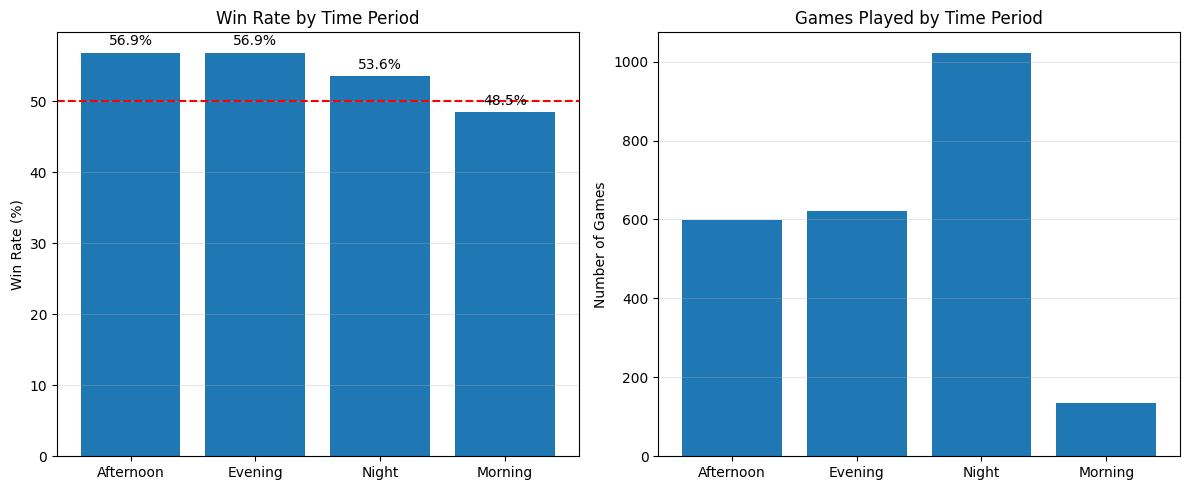

In [68]:
# Convert Time to hour if it's datetime
if pd.api.types.is_datetime64_any_dtype(games_df["Time"]):
    games_df["hour"] = games_df["Time"].dt.hour
else:
    # If Time is string like "14:30", convert it
    games_df["hour"] = pd.to_datetime(
        games_df["Time"], format="%H:%M", errors="coerce"
    ).dt.hour


# Define time periods
def get_time_period(hour):
    if 5 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 21:
        return "Evening"
    else:
        return "Night"


games_df["time_period"] = games_df["hour"].apply(get_time_period)

# Win rate by time period
time_winrate = (
    games_df.groupby("time_period")
    .agg({"is_win": lambda x: x.mean() * 100, "uuid": "count"})
    .round(1)
)

print("Win rate by time period:")
print(time_winrate.sort_values("is_win", ascending=False))

# Also check accuracy by time period (if you have accuracy per game)
if "my_accuracy" in games_df.columns:
    time_accuracy = games_df.groupby("time_period")["my_accuracy"].mean().round(1)
    print("\nAverage accuracy by time period:")
    print(time_accuracy.sort_values(ascending=False))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Win rate plot
time_winrate_sorted = time_winrate.sort_values("is_win", ascending=False)
axes[0].bar(time_winrate_sorted.index, time_winrate_sorted["is_win"])
axes[0].axhline(y=50, color="red", linestyle="--")
axes[0].set_ylabel("Win Rate (%)")
axes[0].set_title("Win Rate by Time Period")
axes[0].grid(axis="y", alpha=0.3)

# Add value labels
for i, v in enumerate(time_winrate_sorted["is_win"]):
    axes[0].text(i, v + 1, f"{v:.1f}%", ha="center")

# Games played by time period
axes[1].bar(time_winrate_sorted.index, time_winrate_sorted["uuid"])
axes[1].set_ylabel("Number of Games")
axes[1].set_title("Games Played by Time Period")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()